In [1]:
!pip uninstall -y modAl

In [2]:
!pip install git+https://github.com/modAL-python/modAL.git

  Cloning https://github.com/modAL-python/modAL.git to /tmp/pip-req-build-1_to5zu1
  Running command git clone --filter=blob:none --quiet https://github.com/modAL-python/modAL.git /tmp/pip-req-build-1_to5zu1
  Resolved https://github.com/modAL-python/modAL.git to commit bba6f6fd00dbb862b1e09259b78caf6cffa2e755
  Preparing metadata (setup.py) ... done


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from modAL.models import ActiveLearner
from modAL.uncertainty import uncertainty_sampling, classifier_entropy

In [4]:
# Define transforms
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load CIFAR-10 dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

Files already downloaded and verified
Files already downloaded and verified


In [5]:
# Define the CNN model
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten the tensor dynamically
        # Use reshape instead of view to flatten the tensor
        x = x.reshape(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# Initialize the CNN model
net = Net()

In [6]:
#net = net.half() # Use 16-bit Floating Point Precision: This reduces the amount of data processed and can significantly speed up computations, though it might be overkill for small models.

In [7]:
# Custom PyTorch model wrapper with a fit method
class PytorchModelWrapper:
    def __init__(self, model):
        self.model = model
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = optim.SGD(self.model.parameters(), lr=0.001, momentum=0.9)

    def fit(self, X, y, epochs=1):
        self.model.train()
        # Reshape input to [batch_size, channels, height, width]
        X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
        y_tensor = torch.tensor(y, dtype=torch.long)

        for epoch in range(epochs):
          # Forward pass
          outputs = self.model(X_tensor)
          loss = self.criterion(outputs, y_tensor)

          # Backward pass and optimize
          self.optimizer.zero_grad()
          loss.backward()
          self.optimizer.step()

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            # Reshape input to [batch_size, channels, height, width]
            X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
            outputs = self.model(X_tensor)
            _, predicted = torch.max(outputs.data, 1)
        return predicted.numpy()

    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            # Reshape input to [batch_size, channels, height, width]
            X_tensor = torch.tensor(X, dtype=torch.float32).permute(0, 3, 1, 2)
            outputs = self.model(X_tensor)
            probabilities = nn.functional.softmax(outputs, dim=1)
        return probabilities.numpy()



In [15]:
# Wrap the PyTorch model
wrapped_model = PytorchModelWrapper(net)

# Initialize the Active Learner
learner = ActiveLearner(
    estimator=wrapped_model,
    query_strategy=uncertainty_sampling,
    X_training=np.array(trainset.data[:1200]), y_training=np.array(trainset.targets[:1200])
)

In [9]:
# Initialize lists to store visualizations data
accuracies = []
queries = []
labeled_instances = [1200]  # Starting with 500 labeled instances
queried_images = []


Predicted probability distribution for queried instance 14047:
[[0.09425388 0.10150218 0.0754256  0.10291947 0.10798126 0.10844419
  0.10598212 0.0967292  0.0972104  0.10955174]]


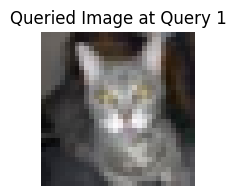

Worst (most uncertain) distribution for instance 10464:
[0.09716303 0.10565209 0.10253378 0.1016543  0.10001528 0.08440948
 0.09929349 0.10203779 0.11090893 0.09633181]
Average distribution for instance 22752:
[0.06995627 0.09274123 0.05779691 0.11151892 0.06652854 0.08227006
 0.10021704 0.0737508  0.14064477 0.20457552]
Best (most confident) distribution for instance 44107:
[0.00865525 0.02752559 0.01537482 0.02250436 0.01974764 0.01671642
 0.0774883  0.02808863 0.06041701 0.723482  ]


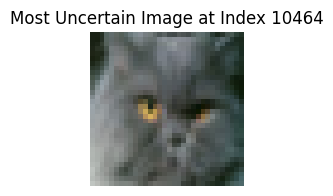

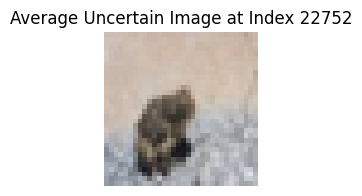

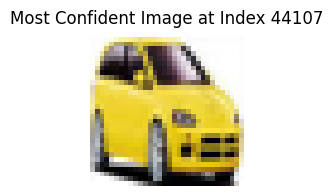

Accuracy after query 1: 10.06%
Predicted probability distribution for queried instance 6253:
[[0.10421648 0.09608048 0.09996402 0.10469956 0.08358048 0.1046297
  0.0963497  0.09813575 0.10603524 0.10630859]]


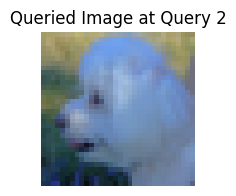

Worst (most uncertain) distribution for instance 40084:
[0.09969963 0.10125304 0.10460041 0.10146326 0.09186998 0.09931493
 0.09302707 0.09692628 0.10430493 0.10754047]
Average distribution for instance 24888:
[0.08116061 0.10161734 0.08458101 0.1021221  0.04850832 0.08394213
 0.12847829 0.1385527  0.07430563 0.15673184]
Best (most confident) distribution for instance 49960:
[0.01374523 0.02452276 0.03099095 0.05205201 0.07598488 0.03704488
 0.10260629 0.09324365 0.03225089 0.53755844]


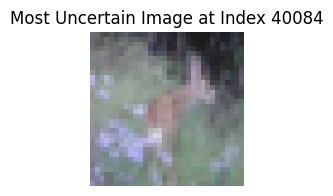

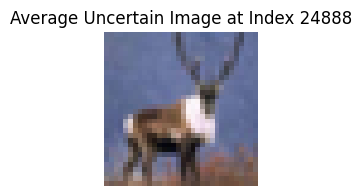

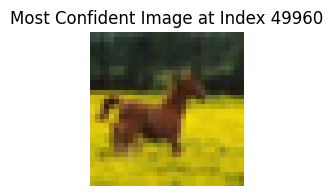

Accuracy after query 2: 10.03%
Predicted probability distribution for queried instance 31186:
[[0.09792584 0.09972568 0.0996718  0.10263745 0.1027253  0.10254145
  0.10303595 0.10569549 0.0886856  0.09735554]]


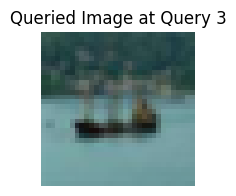

Worst (most uncertain) distribution for instance 24397:
[0.0950537  0.09456827 0.10086205 0.10290468 0.09402701 0.0976778
 0.10490322 0.10050235 0.1084426  0.1010583 ]
Average distribution for instance 48800:
[0.07969704 0.12340473 0.11272495 0.09821692 0.0878574  0.12244459
 0.16512808 0.06268909 0.06586099 0.08197617]
Best (most confident) distribution for instance 47091:
[0.02153979 0.06948301 0.05207797 0.03537242 0.05936793 0.09061255
 0.50541943 0.07903291 0.02836577 0.05872814]


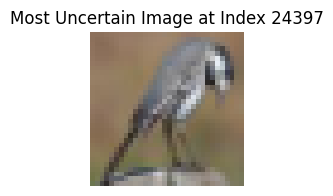

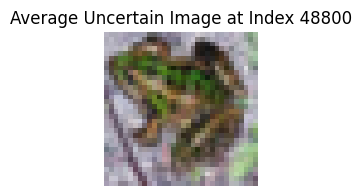

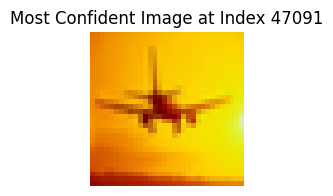

Accuracy after query 3: 10.02%
Predicted probability distribution for queried instance 27239:
[[0.10105129 0.10111932 0.09460627 0.10218436 0.10468978 0.09885415
  0.09496122 0.10352377 0.09630546 0.10270434]]


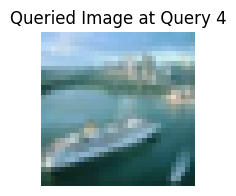

Worst (most uncertain) distribution for instance 27239:
[0.10105129 0.10111932 0.09460627 0.10218436 0.10468978 0.09885415
 0.09496123 0.10352377 0.09630547 0.10270434]
Average distribution for instance 26259:
[0.05487504 0.10893458 0.13654605 0.06893162 0.10737182 0.12045158
 0.15108    0.08519165 0.06862902 0.0979886 ]
Best (most confident) distribution for instance 43872:
[0.02791595 0.13942972 0.06307786 0.00969366 0.20005655 0.08854091
 0.4194095  0.02829952 0.00792467 0.01565172]


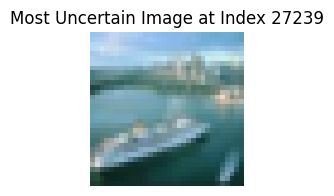

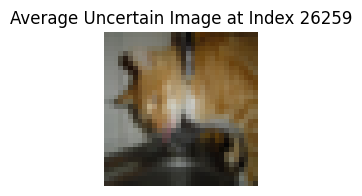

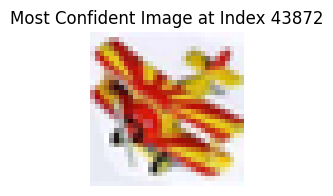

Accuracy after query 4: 10.0%
Predicted probability distribution for queried instance 27471:
[[0.09491382 0.10229598 0.10329745 0.10353458 0.09084239 0.10283577
  0.10510656 0.1001898  0.09651966 0.10046401]]


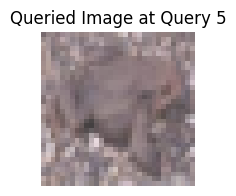

Worst (most uncertain) distribution for instance 25071:
[0.09290629 0.10200366 0.10179329 0.10046053 0.10134801 0.10543937
 0.09479649 0.10308645 0.09494162 0.1032243 ]
Average distribution for instance 39600:
[0.08524431 0.15852718 0.088728   0.08243724 0.11126766 0.09431552
 0.12680097 0.12749068 0.07397709 0.05121139]
Best (most confident) distribution for instance 43871:
[0.02954547 0.15795083 0.0682987  0.01038657 0.20043468 0.08142217
 0.40532523 0.02905791 0.00694807 0.01063031]


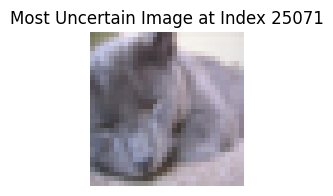

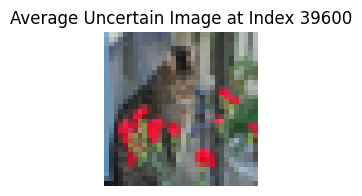

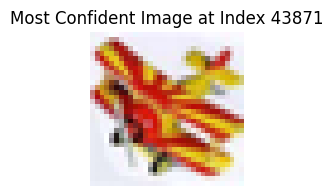

Accuracy after query 5: 10.0%
Predicted probability distribution for queried instance 8484:
[[0.10115357 0.10197638 0.10529371 0.09683993 0.10495145 0.08878022
  0.09099786 0.10600812 0.1025314  0.10146739]]


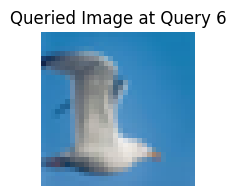

Worst (most uncertain) distribution for instance 32823:
[0.09821969 0.10034791 0.0985221  0.10049103 0.09687562 0.09350738
 0.09689128 0.10793481 0.10589077 0.10131939]
Average distribution for instance 40212:
[0.07420657 0.09191559 0.11044403 0.06662107 0.1057536  0.1359059
 0.16230847 0.09011465 0.06767166 0.09505848]
Best (most confident) distribution for instance 43870:
[0.03195309 0.16891676 0.07073891 0.01318563 0.19511655 0.07955287
 0.3916136  0.03195072 0.00737701 0.00959476]


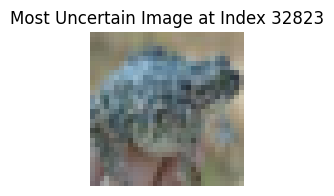

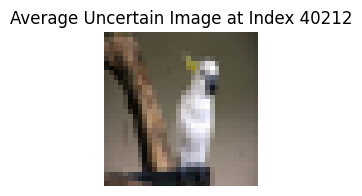

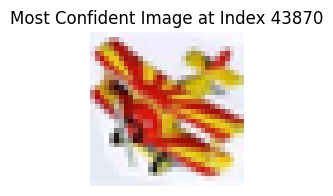

Accuracy after query 6: 10.0%
Predicted probability distribution for queried instance 4119:
[[0.09967558 0.10168839 0.10422257 0.1018454  0.10384419 0.10121576
  0.10273727 0.10080078 0.09268177 0.09128834]]


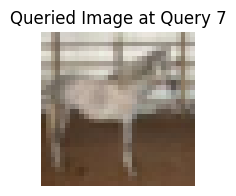

Worst (most uncertain) distribution for instance 15108:
[0.10806512 0.09900144 0.10292796 0.09590113 0.10232536 0.10051996
 0.09543499 0.09971311 0.0943132  0.10179766]
Average distribution for instance 1748:
[0.10123768 0.15087771 0.0889634  0.14379676 0.05754715 0.09010709
 0.08329824 0.10007565 0.10015249 0.08394376]
Best (most confident) distribution for instance 43869:
[0.0354559  0.1785779  0.07332107 0.01793788 0.18518898 0.07627323
 0.3787189  0.03657879 0.00835028 0.0095971 ]


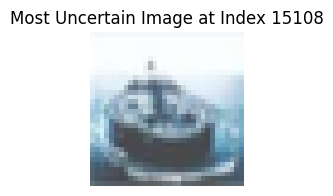

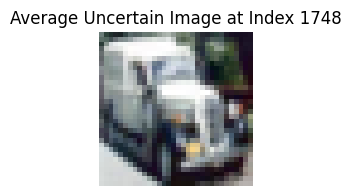

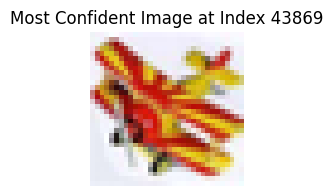

Accuracy after query 7: 10.0%
Predicted probability distribution for queried instance 10906:
[[0.09862587 0.09711439 0.10458831 0.1002983  0.10397393 0.10233265
  0.10076761 0.10354971 0.08893486 0.09981445]]


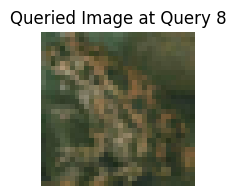

Worst (most uncertain) distribution for instance 33368:
[0.09562521 0.10492956 0.10054316 0.0947907  0.09839163 0.09875076
 0.10429079 0.10452206 0.09985965 0.09829649]
Average distribution for instance 39529:
[0.1085405  0.10084859 0.10390922 0.08169246 0.14204767 0.09705894
 0.11806173 0.12045056 0.06996965 0.05742065]
Best (most confident) distribution for instance 43868:
[0.03884822 0.18599679 0.07835881 0.02360693 0.17380723 0.07143271
 0.36470857 0.04328903 0.00948122 0.0104704 ]


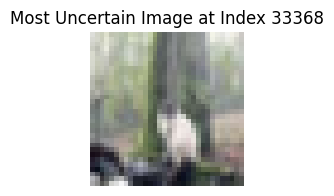

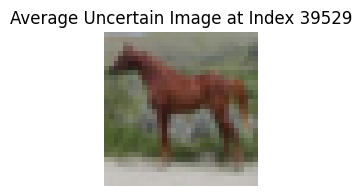

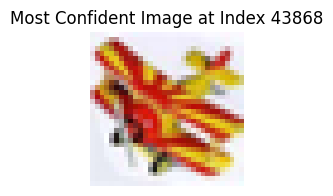

Accuracy after query 8: 10.0%
Predicted probability distribution for queried instance 37390:
[[0.09196411 0.10486464 0.10504781 0.09605602 0.09746319 0.10003893
  0.10530795 0.10075857 0.09905381 0.09944496]]


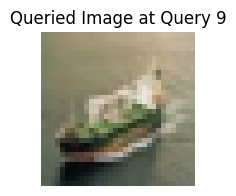

Worst (most uncertain) distribution for instance 33367:
[0.09969194 0.10547763 0.09819545 0.09888595 0.09504144 0.09663897
 0.10305502 0.10569775 0.09967852 0.09763739]
Average distribution for instance 44132:
[0.11894746 0.10981394 0.11821657 0.09375657 0.12565131 0.11146583
 0.09471652 0.10526761 0.05851543 0.06364889]
Best (most confident) distribution for instance 43867:
[0.04140245 0.1895218  0.08424329 0.02979275 0.16186427 0.06679236
 0.35258195 0.05103248 0.01065742 0.01211122]


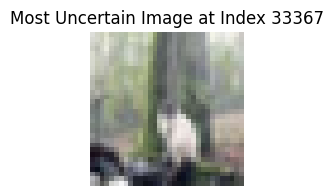

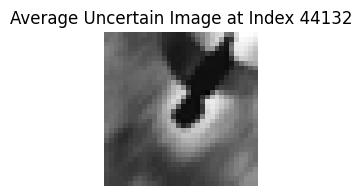

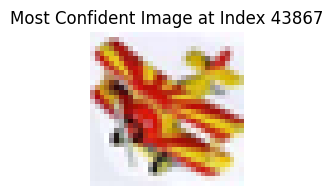

Accuracy after query 9: 10.01%
Predicted probability distribution for queried instance 44759:
[[0.10238875 0.09658021 0.09952416 0.09688588 0.10092133 0.1026431
  0.1030175  0.09922222 0.09928171 0.09953514]]


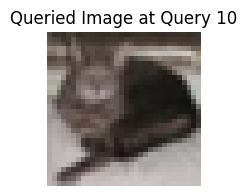

Worst (most uncertain) distribution for instance 44759:
[0.10238875 0.0965802  0.09952416 0.09688587 0.10092131 0.10264308
 0.1030175  0.09922222 0.09928172 0.09953514]
Average distribution for instance 46825:
[0.08816454 0.09721225 0.11101614 0.12747079 0.14143354 0.0812039
 0.10851984 0.0985093  0.06893355 0.0775362 ]
Best (most confident) distribution for instance 8483:
[0.0370088  0.04912022 0.04862645 0.04398512 0.04966702 0.07257597
 0.37583813 0.23060048 0.05212906 0.04044868]


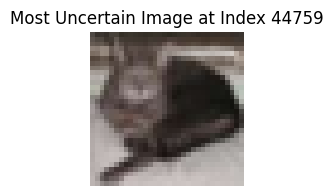

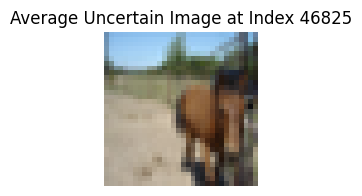

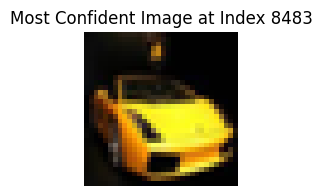

Accuracy after query 10: 10.02%
Predicted probability distribution for queried instance 10653:
[[0.10164767 0.10231566 0.10189529 0.10286103 0.09735678 0.09268206
  0.09120173 0.10390145 0.10344716 0.1026912 ]]


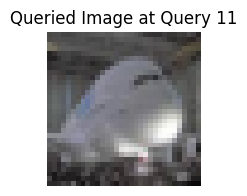

Worst (most uncertain) distribution for instance 40615:
[0.09974763 0.09757728 0.10312598 0.10011396 0.09930211 0.10027267
 0.09435117 0.10712328 0.09629657 0.10208924]
Average distribution for instance 27861:
[0.08870248 0.10786588 0.09517868 0.08351013 0.11995514 0.08125912
 0.11456744 0.14246558 0.09835582 0.06813972]
Best (most confident) distribution for instance 8483:
[0.03700767 0.04918327 0.04565031 0.04502691 0.0464865  0.07103109
 0.37102896 0.23773377 0.05350205 0.04334942]


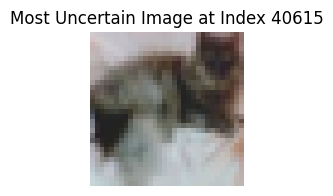

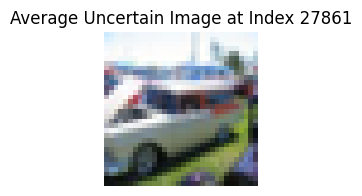

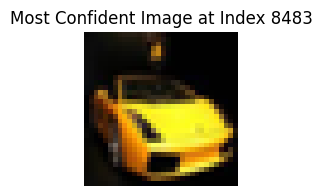

Accuracy after query 11: 10.02%
Predicted probability distribution for queried instance 46647:
[[0.10251337 0.09247711 0.09856501 0.10470761 0.0995334  0.10004221
  0.09394857 0.10103744 0.10424894 0.10292635]]


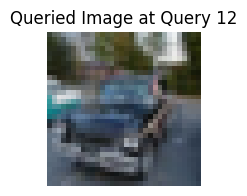

Worst (most uncertain) distribution for instance 20854:
[0.10062017 0.10570256 0.10069475 0.10395502 0.0957901  0.09579776
 0.09590822 0.10367934 0.09836711 0.099485  ]
Average distribution for instance 34175:
[0.0886773  0.11786888 0.11168371 0.12687007 0.11881869 0.09928844
 0.10189015 0.10023241 0.06581071 0.06885957]
Best (most confident) distribution for instance 8483:
[0.03646351 0.04922578 0.04262029 0.04600161 0.04399662 0.06945944
 0.3667824  0.24401574 0.05382703 0.04760765]


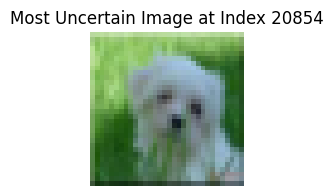

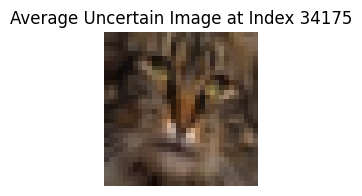

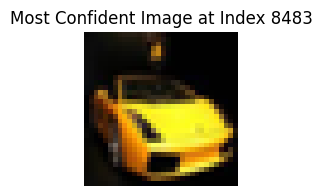

Accuracy after query 12: 10.01%
Predicted probability distribution for queried instance 31014:
[[0.09434649 0.09349024 0.1047582  0.10470699 0.10131811 0.103948
  0.10063328 0.10006722 0.09480306 0.10192835]]


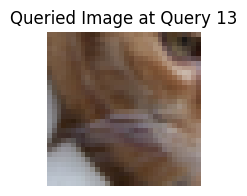

Worst (most uncertain) distribution for instance 37979:
[0.09497458 0.10733705 0.10414138 0.10126458 0.09924166 0.09634687
 0.10042373 0.09774107 0.0978268  0.10070218]
Average distribution for instance 5706:
[0.09715018 0.10808387 0.11473172 0.09069325 0.12173186 0.06511252
 0.10332757 0.12914647 0.07058103 0.09944157]
Best (most confident) distribution for instance 22757:
[0.05768974 0.04326899 0.02657451 0.05202426 0.06604546 0.05082618
 0.33150658 0.28913802 0.04863496 0.03429137]


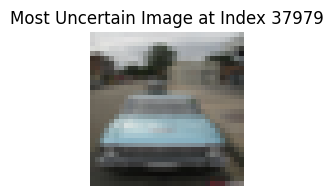

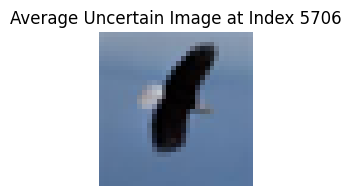

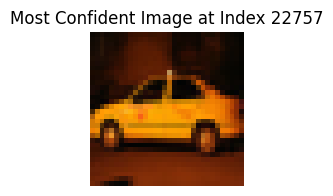

Accuracy after query 13: 10.02%
Predicted probability distribution for queried instance 48286:
[[0.10408257 0.10379816 0.10341734 0.1050247  0.1042102  0.09878269
  0.09074911 0.10466826 0.08308229 0.10218471]]


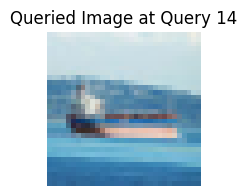

Worst (most uncertain) distribution for instance 37978:
[0.09535452 0.10838022 0.10485376 0.10081184 0.10075836 0.09827819
 0.10031507 0.09752856 0.09572132 0.09799826]
Average distribution for instance 23961:
[0.1076652  0.1050532  0.1458984  0.10219314 0.07927551 0.09030146
 0.09598773 0.1093644  0.06413861 0.10012244]
Best (most confident) distribution for instance 22757:
[0.05304977 0.04199195 0.02442656 0.05025913 0.05990217 0.04669725
 0.34407762 0.29371095 0.04842216 0.03746247]


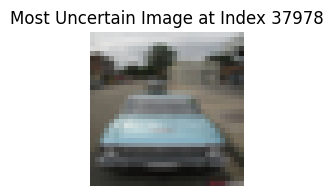

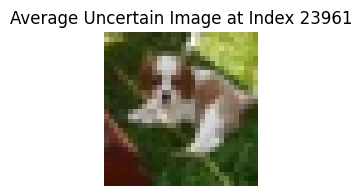

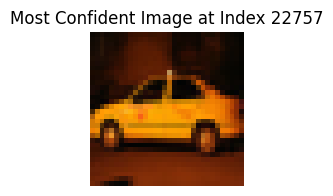

Accuracy after query 14: 10.02%
Predicted probability distribution for queried instance 5649:
[[0.10163146 0.09706873 0.1051558  0.1013111  0.10083168 0.1048356
  0.08489539 0.10379717 0.09641419 0.10405888]]


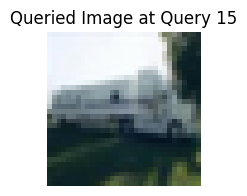

Worst (most uncertain) distribution for instance 13408:
[0.10233744 0.10086924 0.10218292 0.10639954 0.10257643 0.09198572
 0.09749448 0.10092441 0.09727231 0.09795751]
Average distribution for instance 6036:
[0.07738077 0.10237141 0.06279178 0.11264897 0.08395587 0.10711324
 0.11946584 0.1225369  0.08568155 0.12605369]
Best (most confident) distribution for instance 22757:
[0.04800753 0.04004236 0.02240672 0.04760136 0.05465016 0.04289625
 0.35580766 0.30035767 0.04676702 0.04146331]


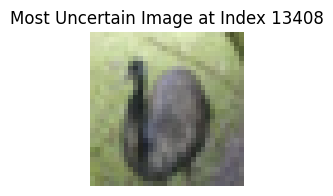

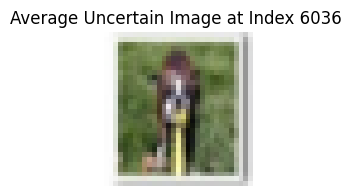

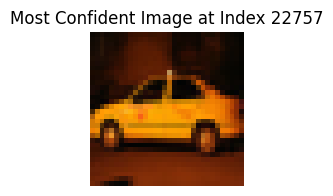

Accuracy after query 15: 10.02%
Predicted probability distribution for queried instance 21703:
[[0.10459923 0.10313933 0.10523014 0.1021495  0.10464747 0.0911642
  0.09571689 0.10212191 0.08888575 0.10234561]]


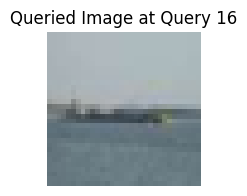

Worst (most uncertain) distribution for instance 13407:
[0.09974232 0.10173465 0.09848137 0.10610738 0.10011147 0.09153003
 0.10303792 0.10286077 0.09465694 0.10173713]
Average distribution for instance 20588:
[0.06961101 0.13134363 0.08019539 0.115609   0.07589675 0.09971891
 0.10835297 0.10009989 0.08416036 0.13501215]
Best (most confident) distribution for instance 22756:
[0.04304354 0.03882188 0.02097006 0.04613172 0.05028304 0.03974128
 0.36146036 0.30848905 0.04476356 0.0462955 ]


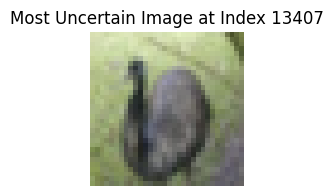

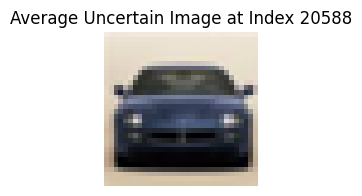

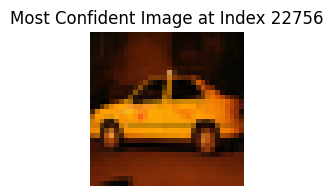

Accuracy after query 16: 10.03%
Predicted probability distribution for queried instance 33704:
[[0.10023945 0.09681318 0.1054512  0.10522839 0.10565306 0.09568018
  0.09946274 0.10551186 0.08851464 0.09744534]]


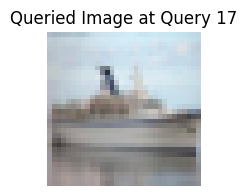

Worst (most uncertain) distribution for instance 15623:
[0.09463734 0.1058922  0.10679223 0.0993497  0.10165976 0.09796717
 0.09369051 0.09935138 0.10375448 0.09690525]
Average distribution for instance 48308:
[0.07712535 0.14948283 0.11977536 0.08538546 0.09627753 0.07958145
 0.07660399 0.09827001 0.09016991 0.1273281 ]
Best (most confident) distribution for instance 22755:
[0.03891605 0.03718667 0.01937382 0.04462527 0.04606931 0.03655404
 0.36582994 0.31667438 0.04277083 0.05199962]


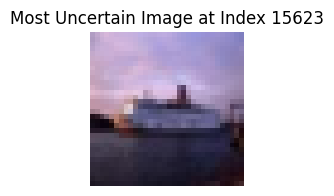

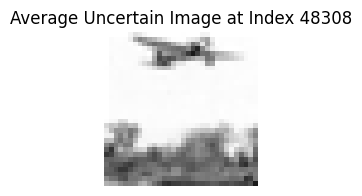

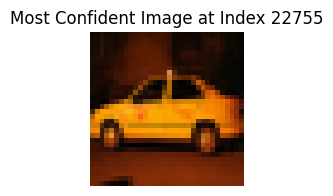

Accuracy after query 17: 10.04%
Predicted probability distribution for queried instance 44470:
[[0.10136929 0.09559052 0.10594537 0.09835983 0.10173851 0.09542125
  0.0952995  0.10553705 0.0968069  0.10393181]]


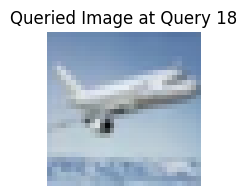

Worst (most uncertain) distribution for instance 15623:
[0.09632573 0.10452162 0.10627268 0.09643704 0.10268637 0.09694497
 0.09580237 0.10011957 0.10400138 0.09688833]
Average distribution for instance 35780:
[0.10633977 0.13404097 0.10900758 0.10278647 0.12227042 0.0771712
 0.12358224 0.07985076 0.0550347  0.08991583]
Best (most confident) distribution for instance 22755:
[0.03594215 0.03568567 0.01798774 0.04299895 0.04202763 0.0337428
 0.3679238  0.3229719  0.0412726  0.05944668]


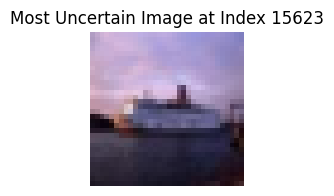

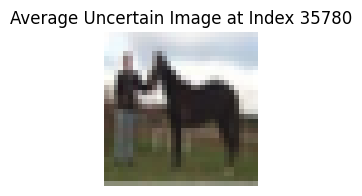

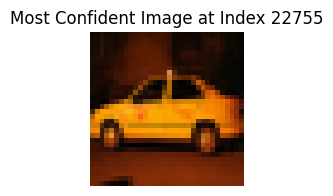

Accuracy after query 18: 10.05%
Predicted probability distribution for queried instance 22291:
[[0.10533287 0.10570636 0.10473152 0.09769802 0.1036623  0.09166977
  0.09044646 0.10554565 0.09432399 0.10088308]]


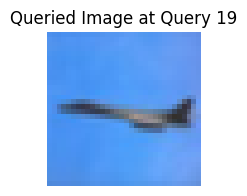

Worst (most uncertain) distribution for instance 15623:
[0.09759695 0.10437575 0.10601626 0.09508886 0.10148254 0.09665062
 0.09672326 0.09980922 0.10472346 0.09753305]
Average distribution for instance 19843:
[0.07939826 0.09097088 0.08218002 0.09710759 0.11183371 0.10607305
 0.13944897 0.14335376 0.05787505 0.09175868]
Best (most confident) distribution for instance 22755:
[0.03417565 0.03475947 0.01693796 0.04120163 0.03813562 0.03142357
 0.3678393  0.32624924 0.04033465 0.06894281]


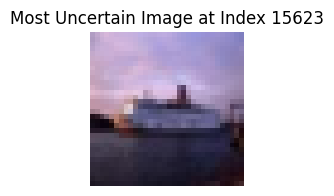

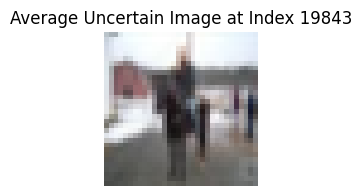

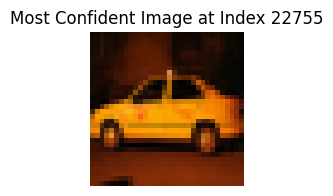

Accuracy after query 19: 10.05%
Predicted probability distribution for queried instance 9626:
[[0.10409635 0.10446066 0.10582417 0.10119542 0.10446022 0.10183006
  0.08534342 0.10328678 0.09732209 0.09218077]]


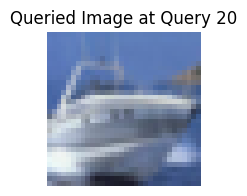

Worst (most uncertain) distribution for instance 15623:
[0.09912395 0.10664322 0.10521337 0.09475926 0.09942116 0.09624245
 0.09660737 0.09892268 0.1058882  0.09717831]
Average distribution for instance 25716:
[0.10298029 0.17354016 0.10497647 0.10408465 0.07076721 0.09125333
 0.10992841 0.0828525  0.07294925 0.08666771]
Best (most confident) distribution for instance 22754:
[0.033709   0.03444837 0.01614336 0.03865954 0.03466558 0.02981763
 0.36600143 0.32747224 0.03966651 0.0794163 ]


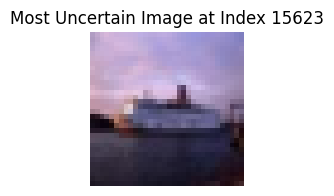

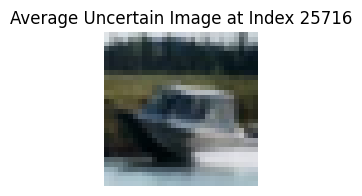

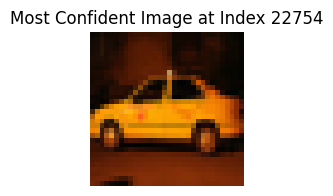

Accuracy after query 20: 10.04%


In [16]:
# Active learning loop
n_queries = 20

for i in range(n_queries):

    # Get the point which we label next
    batch_size = 10
    query_idx, query_instance = learner.query(np.array(trainset.data))
    # Extract the integer index from the array
    query_idx = query_idx[0]

    # Get the probability distribution of the selected instance
    predicted_probabilities = learner.predict_proba(np.array([trainset.data[query_idx]]))

    # Print the probability distribution
    print(f"Predicted probability distribution for queried instance {query_idx}:")
    print(predicted_probabilities)

    # Display the queried image
    queried_image = trainset.data[query_idx]
    plt.figure(figsize=(2, 2))
    plt.imshow(queried_image)
    plt.title(f'Queried Image at Query {i + 1}')
    plt.axis('off')
    plt.show()


    ###


    # Get probabilities for all instances in the pool
    all_probabilities = learner.predict_proba(np.array(trainset.data))

    # Calculate entropy for each instance to measure uncertainty
    entropy = -np.sum(all_probabilities * np.log(all_probabilities + 1e-9), axis=1)

    # Sort instances by entropy to find the most uncertain, average, and most confident
    sorted_indices = np.argsort(entropy)

    # Most uncertain (highest entropy)
    worst_idx = sorted_indices[-1]
    worst_probabilities = all_probabilities[worst_idx]
    print(f"Worst (most uncertain) distribution for instance {worst_idx}:")
    print(worst_probabilities)

    # Average uncertain (middle of the list)
    average_idx = sorted_indices[len(sorted_indices) // 2]
    average_probabilities = all_probabilities[average_idx]
    print(f"Average distribution for instance {average_idx}:")
    print(average_probabilities)

    # Most confident (lowest entropy)
    best_idx = sorted_indices[0]
    best_probabilities = all_probabilities[best_idx]
    print(f"Best (most confident) distribution for instance {best_idx}:")
    print(best_probabilities)

    # Display the worst image
    plt.figure(figsize=(2, 2))
    plt.imshow(trainset.data[worst_idx])
    plt.title(f'Most Uncertain Image at Index {worst_idx}')
    plt.axis('off')
    plt.show()

    # Display the average image
    plt.figure(figsize=(2, 2))
    plt.imshow(trainset.data[average_idx])
    plt.title(f'Average Uncertain Image at Index {average_idx}')
    plt.axis('off')
    plt.show()

    # Display the best image
    plt.figure(figsize=(2, 2))
    plt.imshow(trainset.data[best_idx])
    plt.title(f'Most Confident Image at Index {best_idx}')
    plt.axis('off')
    plt.show()


    ###





    # Simulate the oracle by selecting the label from the training set
    learner.teach(np.array([trainset.data[query_idx]]), np.array([trainset.targets[query_idx]]))


     # Append the queried image to the list
    queried_image = trainset.data[query_idx]
    queried_images.append((queried_image, i + 1))

    # Remove the queried instance from the pool
    trainset.data = np.delete(trainset.data, query_idx, axis=0)
    trainset.targets = np.delete(trainset.targets, query_idx, axis=0)

    # Update the number of labeled instances
    labeled_instances.append(len(learner.X_training))

    # Evaluate performance after each query
    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            outputs = net(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    accuracies.append(accuracy)
    queries.append(i + 1)
    print(f'Accuracy after query {i + 1}: {accuracy}%')



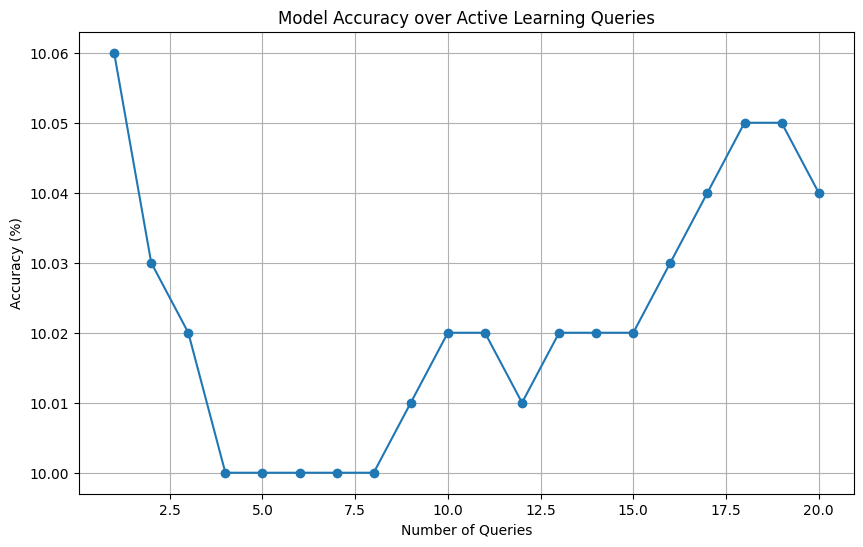

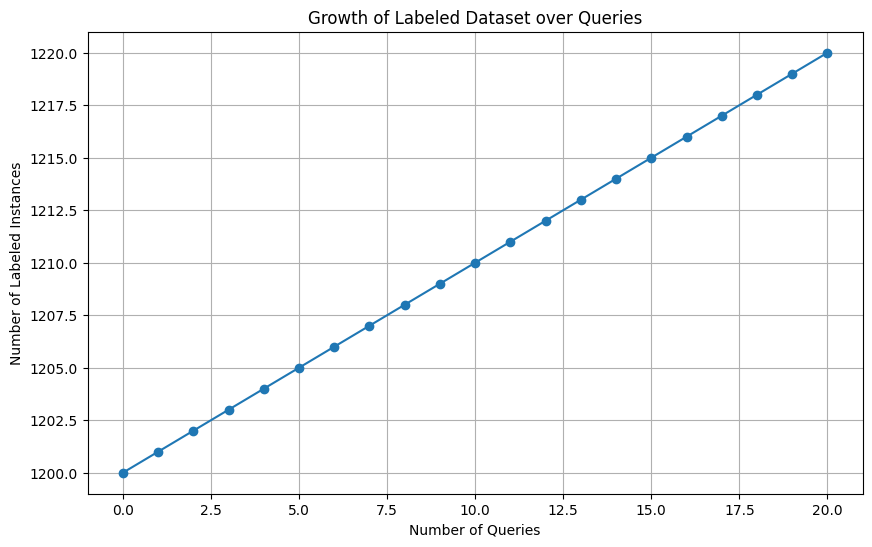

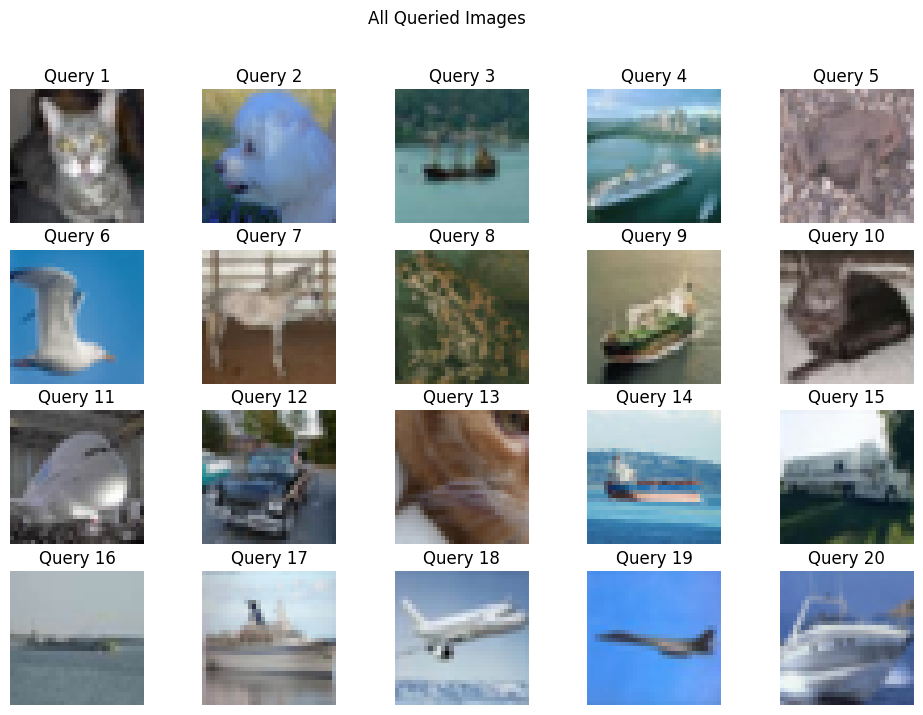

In [17]:
# Visualizing accuracy progression over time
plt.figure(figsize=(10, 6))
plt.plot(queries, accuracies, marker='o')
plt.title('Model Accuracy over Active Learning Queries')
plt.xlabel('Number of Queries')
plt.ylabel('Accuracy (%)')
plt.grid(True)
plt.show()

# Visualizing the growth of labeled data
plt.figure(figsize=(10, 6))
plt.plot(range(n_queries + 1), labeled_instances, marker='o')
plt.title('Growth of Labeled Dataset over Queries')
plt.xlabel('Number of Queries')
plt.ylabel('Number of Labeled Instances')
plt.grid(True)
plt.show()

# Displaying all queried images
plt.figure(figsize=(12, 8))
for idx, (image, query_number) in enumerate(queried_images):
    plt.subplot(4, 5, idx + 1)  # Assuming 10 queries, adjust grid size as needed
    plt.imshow(image)
    plt.title(f'Query {query_number}')
    plt.axis('off')
plt.suptitle('All Queried Images')
plt.show()

In [18]:
# Final evaluation
correct = 0
total = 0
with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Final accuracy after {n_queries} queries: {100 * correct / total}%')

Final accuracy after 20 queries: 10.04%
